<a href="https://colab.research.google.com/github/clobos/Python_Tatiana_Ecologia_Aplicada/blob/main/Cod_Completo_Campinas_Cristian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# agora configurar o banco de dados no drive que VAI FUNCIONAR
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
file_path = '/content/drive/MyDrive/0_ATALHOS/17_Tatiana_Ecologia_Aplicada.lnk.lnk/Shared - Mestrado Tatiana /Cristian_drive/Dados/df_CAMPINAS.xlsx'


file_path
df = pd.read_excel(file_path)

# Exibir as primeiras 5 linhas do DataFrame para verificar o carregamento
display(df.head())

,Ano,RDO_RPU
0,2002,248552.6
1,2003,230671.5
2,2004,264000.0
3,2005,241375.7
4,2006,273778.6


### 3. Preparação dos Dados para Modelagem de Séries Temporais
Para usar modelos como o Prophet, precisamos que a coluna de tempo seja em formato de data e que as colunas sejam renomeadas para `ds` (data) e `y` (valor a ser previsto).

In [6]:
# Verificar tipos de dados
df.info()

# Exibir as primeiras 5 linhas do DataFrame atualizado
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ano      21 non-null     int64  
 1   RDO_RPU  21 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes


,Ano,RDO_RPU
0,2002,248552.6
1,2003,230671.5
2,2004,264000.0
3,2005,241375.7
4,2006,273778.6


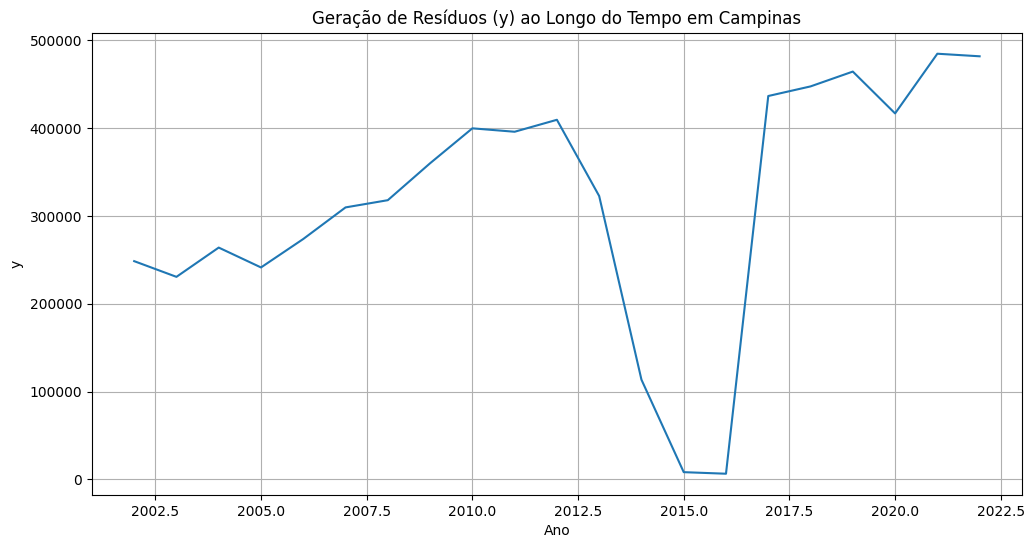

In [8]:
# Criar um gráfico de linhas para visualizar a variável 'y' ao longo do tempo 'ds'
plt.figure(figsize=(12, 6))
sns.lineplot(x='Ano', y='RDO_RPU', data=df)
plt.title('Geração de Resíduos (y) ao Longo do Tempo em Campinas')
plt.xlabel('Ano')
plt.ylabel('y')
plt.grid(True)
plt.show()

### 3.1 Preparação dos Dados para Modelagem

In [9]:
# Converter 'Ano' para formato datetime e renomear colunas para 'ds' e 'y'
df_ts = df.rename(columns={'Ano': 'ds', 'RDO_RPU': 'y'})
df_ts['ds'] = pd.to_datetime(df_ts['ds'], format='%Y')

# Definir 'ds' como índice para séries temporais
df_ts = df_ts.set_index('ds')

# Exibir as primeiras linhas do DataFrame preparado
display(df_ts.head())

# Exibir informações para confirmar os tipos de dados
df_ts.info()

,y
ds,
2002-01-01,248552.6
2003-01-01,230671.5
2004-01-01,264000.0
2005-01-01,241375.7
2006-01-01,273778.6


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21 entries, 2002-01-01 to 2022-01-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       21 non-null     float64
dtypes: float64(1)
memory usage: 336.0 bytes


### 3.2 Divisão dos Dados em Treino e Teste
Usaremos os dados até 2019 para treinar os modelos e os dados de 2020 a 2022 para avaliação.

In [10]:
# Dividir os dados em treino e teste
train_end_year = 2019
train_data = df_ts[df_ts.index.year <= train_end_year]
test_data = df_ts[df_ts.index.year > train_end_year]

print(f"Tamanho dos dados de treino: {len(train_data)}")
print(f"Tamanho dos dados de teste: {len(test_data)}")

display(train_data.head())
display(test_data.head())

Tamanho dos dados de treino: 18
Tamanho dos dados de teste: 3


,y
ds,
2002-01-01,248552.6
2003-01-01,230671.5
2004-01-01,264000.0
2005-01-01,241375.7
2006-01-01,273778.6


,y
ds,
2020-01-01,416764.0
2021-01-01,484734.8
2022-01-01,481805.0


### 3.3 Análise das Características da Série Temporal
Vamos verificar a estacionariedade e as funções de autocorrelação para entender a estrutura da série.

In [ ]:
# Instalar pmdarima para auto_arima (se não estiver instalado)
#!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00
Teste ADF para a série original:
Teste ADF - P-valor: 0.0203
Rejeita a hipótese nula (H0), a série é estacionária.


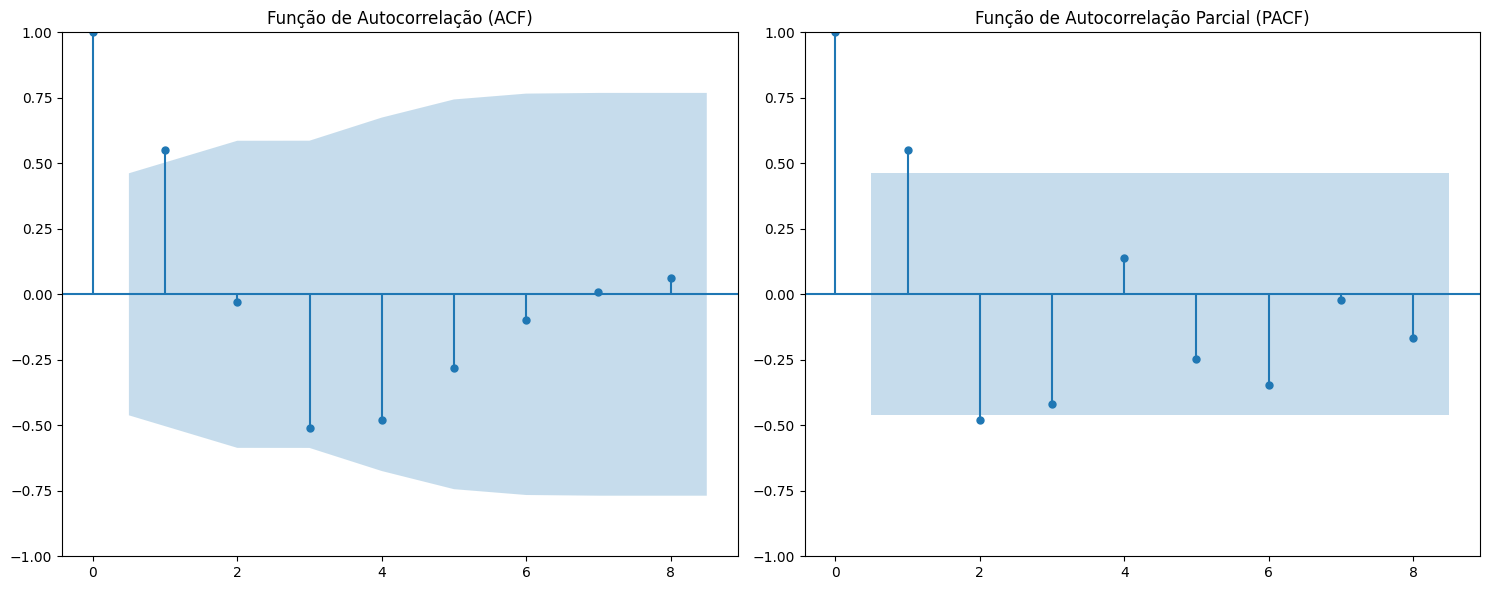

In [13]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Teste de Dickey-Fuller Aumentado para estacionariedade
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'Teste ADF - P-valor: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Rejeita a hipótese nula (H0), a série é estacionária.")
    else:
        print("Não rejeita a hipótese nula (H0), a série não é estacionária.")

print("Teste ADF para a série original:")
adf_test(train_data['y'])

# Plotar ACF e PACF para identificar ordens de ARIMA
plt.figure(figsize=(15, 6))
plt.subplot(121)
plot_acf(train_data['y'], lags=len(train_data)//2 - 1, ax=plt.gca())
plt.title('Função de Autocorrelação (ACF)')

plt.subplot(122)
plot_pacf(train_data['y'], lags=len(train_data)//2 - 1, ax=plt.gca())
plt.title('Função de Autocorrelação Parcial (PACF)')
plt.tight_layout()
plt.show()

### 3.4 Modelagem ARIMA (Auto)
Vamos utilizar `auto_arima` para encontrar a melhor ordem (p, d, q) para o modelo ARIMA.

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=483.490, Time=0.39 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=509.511, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=478.497, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=500.977, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=479.772, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=480.040, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=482.001, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=474.954, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=479.946, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=472.413, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=470.918, Time=0.05 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=472.922, Time=0.11 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=472.880, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=477.988, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=474.6

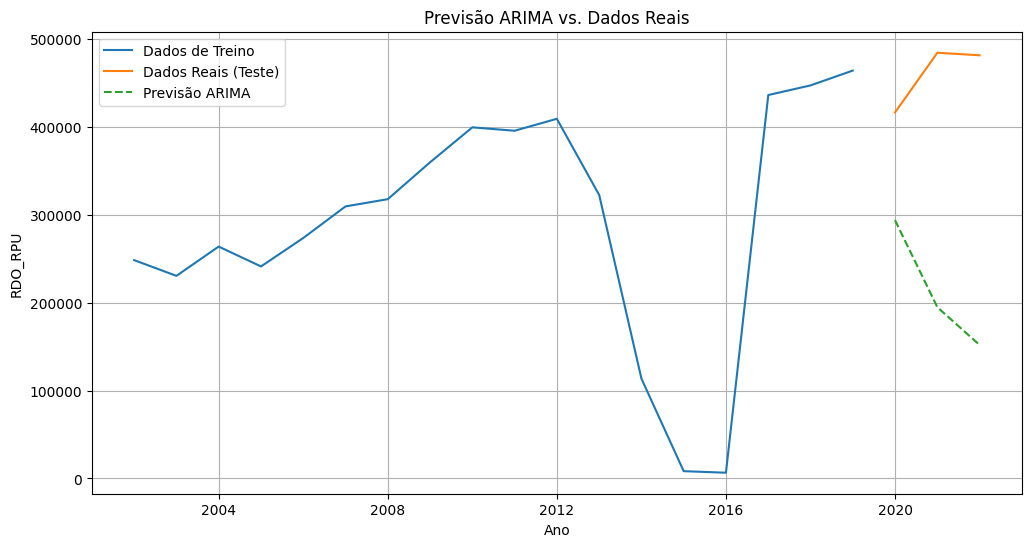

RMSE (ARIMA): 263220.70
MAE (ARIMA): 247466.59


In [14]:
#!pip install pmdarima
import pmdarima as pm

# Ajustar o modelo ARIMA automaticamente
# 'm=1' é usado para dados anuais, significando que não há sazonalidade intra-anual explícita a ser modelada
auto_arima_model = pm.auto_arima(train_data['y'],
                                 seasonal=False, # Definido como False para ARIMA não-sazonal
                                 stepwise=True,
                                 suppress_warnings=True,
                                 trace=True)

print(auto_arima_model.summary())

# Fazer previsões no conjunto de teste
forecast_arima = auto_arima_model.predict(n_periods=len(test_data))
forecast_arima = pd.Series(forecast_arima, index=test_data.index)

# Plotar resultados do ARIMA
plt.figure(figsize=(12, 6))
plt.plot(train_data['y'], label='Dados de Treino')
plt.plot(test_data['y'], label='Dados Reais (Teste)')
plt.plot(forecast_arima, label='Previsão ARIMA', linestyle='--')
plt.title('Previsão ARIMA vs. Dados Reais')
plt.xlabel('Ano')
plt.ylabel('RDO_RPU')
plt.legend()
plt.grid(True)
plt.show()

# Avaliar o desempenho
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(test_data['y'], forecast_arima))
mae_arima = mean_absolute_error(test_data['y'], forecast_arima)

print(f'RMSE (ARIMA): {rmse_arima:.2f}')
print(f'MAE (ARIMA): {mae_arima:.2f}')

### 3.5 Modelagem SARIMA (Auto)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=475.049, Time=1.09 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=479.946, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=474.954, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=475.326, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=509.511, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=472.413, Time=0.14 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=470.918, Time=0.15 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=472.922, Time=0.39 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=472.880, Time=0.33 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=477.988, Time=0.86 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=474.628, Time=0.88 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=481.741, Time=0.11 sec

Best model:  ARIMA(3,0,0)(0,0,0)[0] intercept
Total fit time: 4.297 seconds
                               SARIMAX Results                                
Dep. Variable:       

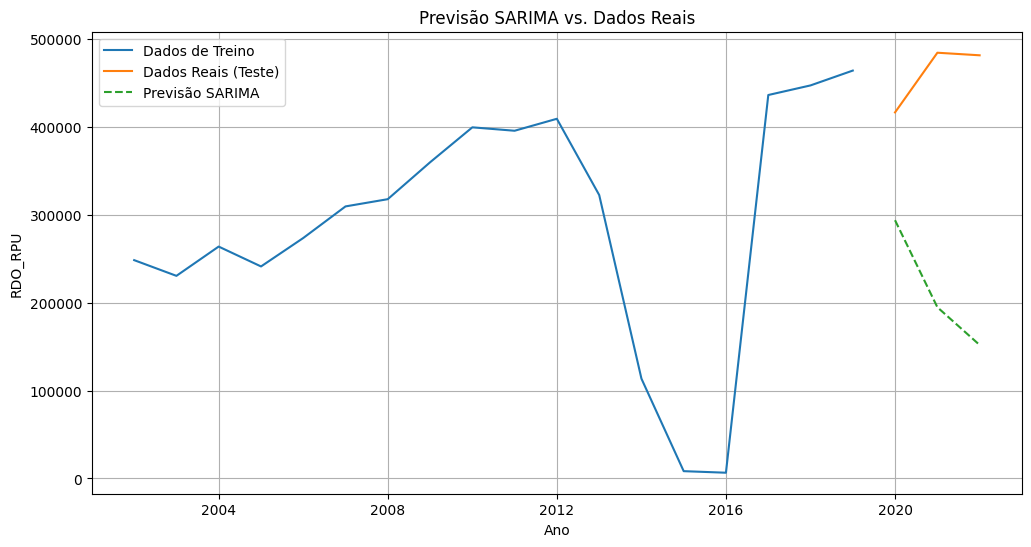

RMSE (SARIMA): 263220.70
MAE (SARIMA): 247466.59


,Modelo,RMSE,MAE
0,ARIMA,263220.702768,247466.591124
1,SARIMA,263220.702768,247466.591124


In [15]:
# Ajustar o modelo SARIMA automaticamente
# 'm=1' para dados anuais, pois não esperamos sazonalidade intra-anual, mas auto_arima explorará ordens sazonais se seasonal=True
auto_sarima_model = pm.auto_arima(train_data['y'],
                                  seasonal=True, # Definido como True para SARIMA sazonal
                                  m=1, # Sazonalidade anual (sem sazonalidade intra-anual explícita)
                                  stepwise=True,
                                  suppress_warnings=True,
                                  trace=True)

print(auto_sarima_model.summary())

# Fazer previsões no conjunto de teste
forecast_sarima = auto_sarima_model.predict(n_periods=len(test_data))
forecast_sarima = pd.Series(forecast_sarima, index=test_data.index)

# Plotar resultados do SARIMA
plt.figure(figsize=(12, 6))
plt.plot(train_data['y'], label='Dados de Treino')
plt.plot(test_data['y'], label='Dados Reais (Teste)')
plt.plot(forecast_sarima, label='Previsão SARIMA', linestyle='--')
plt.title('Previsão SARIMA vs. Dados Reais')
plt.xlabel('Ano')
plt.ylabel('RDO_RPU')
plt.legend()
plt.grid(True)
plt.show()

# Avaliar o desempenho
rmse_sarima = np.sqrt(mean_squared_error(test_data['y'], forecast_sarima))
mae_sarima = mean_absolute_error(test_data['y'], forecast_sarima)

print(f'RMSE (SARIMA): {rmse_sarima:.2f}')
print(f'MAE (SARIMA): {mae_sarima:.2f}')

# Armazenar métricas para comparação futura
metrics_df = pd.DataFrame({
    'Modelo': ['ARIMA', 'SARIMA'],
    'RMSE': [rmse_arima, rmse_sarima],
    'MAE': [mae_arima, mae_sarima]
})
display(metrics_df)

### 3.6 Modelagem ETS (Exponential Smoothing)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                   18
Model:             ExponentialSmoothing   SSE                   254273251403.663
Optimized:                         True   AIC                            428.683
Trend:                         Additive   BIC                            432.245
Seasonal:                          None   AICC                           436.320
Seasonal Periods:                  None   Date:                 Wed, 06 May 2026
Box-Cox:                          False   Time:                         07:51:36
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
smoothing_trend             0.0000

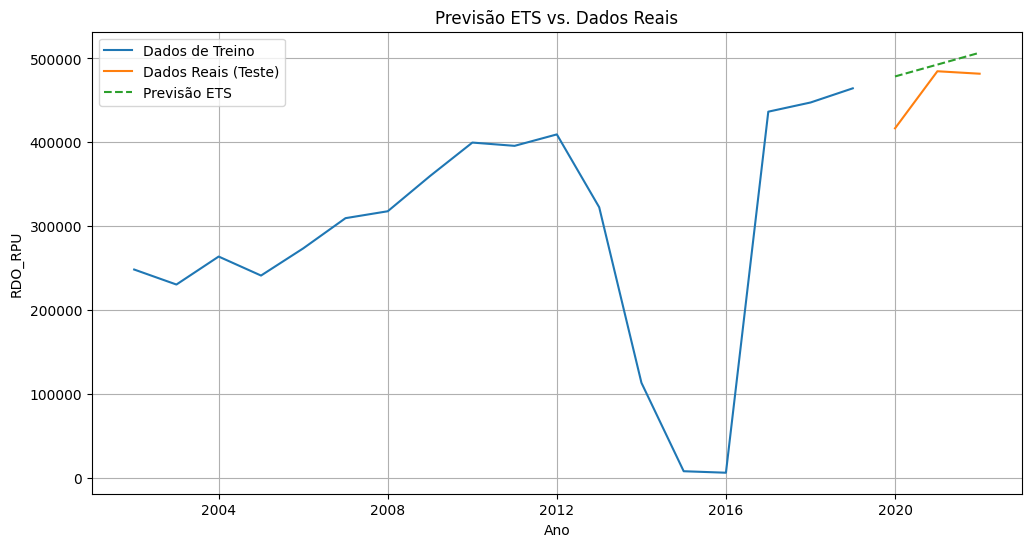

RMSE (ETS): 38750.51
MAE (ETS): 31574.96


,Modelo,RMSE,MAE
0,ARIMA,263220.702768,247466.591124
1,SARIMA,263220.702768,247466.591124
2,ETS,38750.507127,31574.955733


In [17]:
from statsmodels.tsa.api import ExponentialSmoothing

# Ajustar o modelo ETS
# Usamos trend='add' (tendência aditiva) e seasonal=None (sem sazonalidade explícita para dados anuais).
# Para um modelo mais robusto, poderíamos iterar sobre diferentes combinações de error, trend e seasonal.
model_ets = ExponentialSmoothing(train_data['y'], trend='add', seasonal=None, initialization_method="estimated").fit()

print(model_ets.summary())

# Fazer previsões no conjunto de teste
forecast_ets = model_ets.predict(start=test_data.index[0], end=test_data.index[-1])

# Plotar resultados do ETS
plt.figure(figsize=(12, 6))
plt.plot(train_data['y'], label='Dados de Treino')
plt.plot(test_data['y'], label='Dados Reais (Teste)')
plt.plot(forecast_ets, label='Previsão ETS', linestyle='--')
plt.title('Previsão ETS vs. Dados Reais')
plt.xlabel('Ano')
plt.ylabel('RDO_RPU')
plt.legend()
plt.grid(True)
plt.show()

# Avaliar o desempenho
rmse_ets = np.sqrt(mean_squared_error(test_data['y'], forecast_ets))
mae_ets = mean_absolute_error(test_data['y'], forecast_ets)

print(f'RMSE (ETS): {rmse_ets:.2f}')
print(f'MAE (ETS): {mae_ets:.2f}')

# Atualizar o DataFrame de métricas para inclusão do modelo ETS
metrics_df_updated = pd.DataFrame({
    'Modelo': ['ARIMA', 'SARIMA', 'ETS'],
    'RMSE': [rmse_arima, rmse_sarima, rmse_ets],
    'MAE': [mae_arima, mae_sarima, mae_ets]
})
display(metrics_df_updated)


### 3.7 Modelagem e Comparação de Múltiplos Modelos ETS
Vamos explorar diferentes configurações do modelo ETS (Exponential Smoothing) para identificar qual performa melhor na previsão da série temporal. Iremos variar os componentes de tendência (trend) e erro (error), mantendo a sazonalidade como `None` devido à natureza anual dos dados.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)



--- Modelo: ETS (Additive Trend, Additive Error) ---
RMSE: 38750.51
MAE: 31574.96


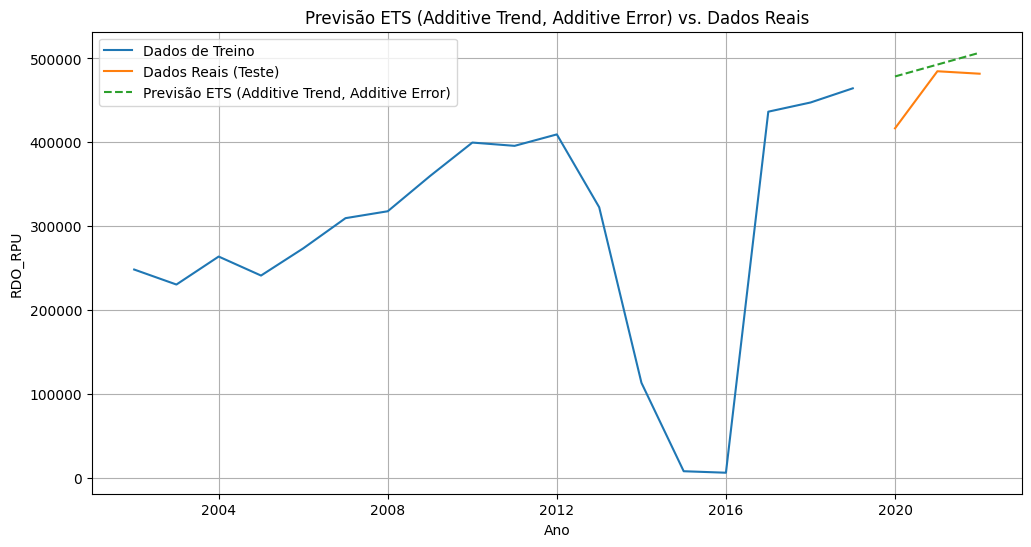

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)



--- Modelo: ETS (Multiplicative Trend, Multiplicative Error) ---
RMSE: 38918.35
MAE: 31929.25


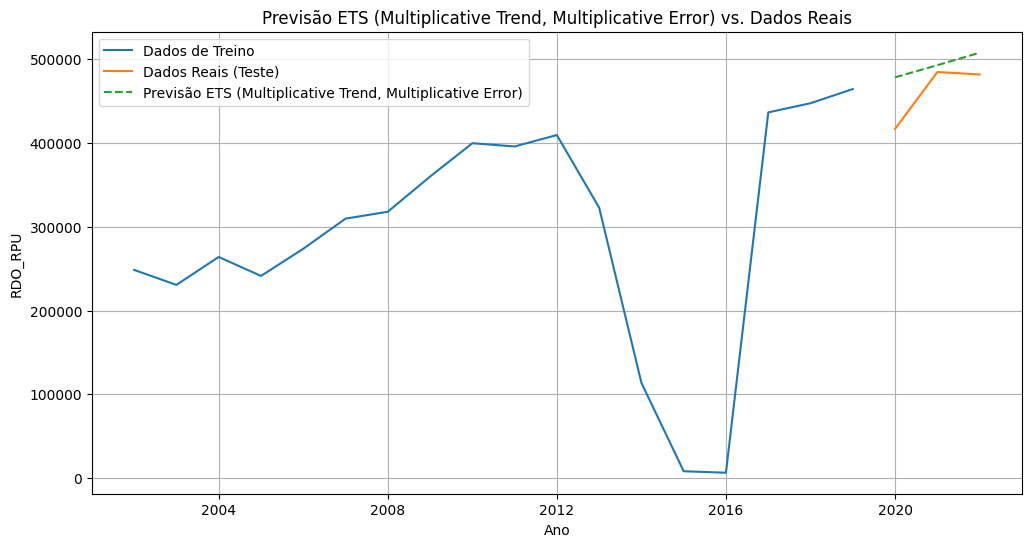

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)



--- Modelo: ETS (No Trend, Additive Error) ---
RMSE: 31547.59
MAE: 28456.50


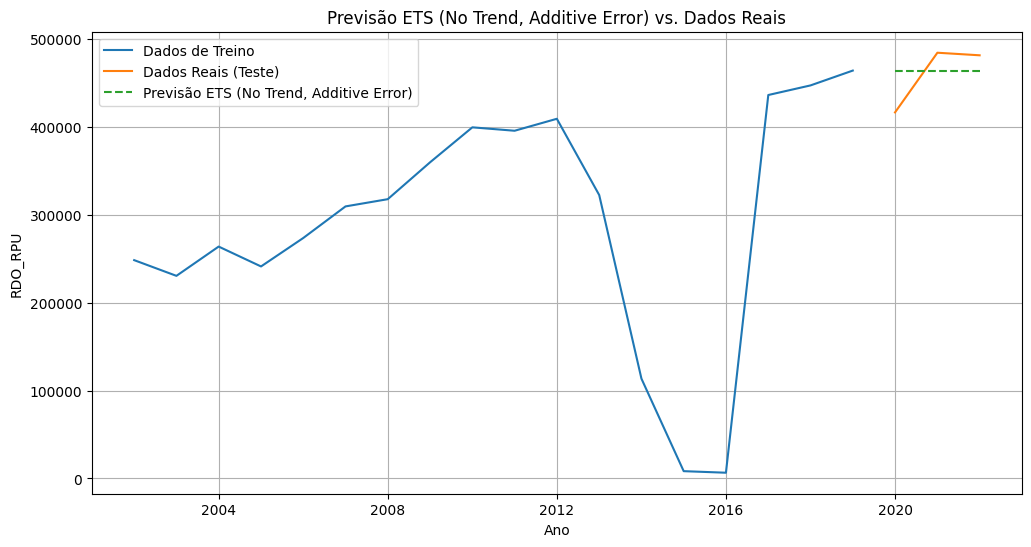


--- Comparativo Final de Métricas de Performance ---


,Modelo,RMSE,MAE
4,"ETS (No Trend, Additive Error)",31547.590601,28456.500084
2,"ETS (Additive Trend, Additive Error)",38750.507127,31574.955733
3,"ETS (Multiplicative Trend, Multiplicative Error)",38918.352111,31929.253314
1,SARIMA,263220.702768,247466.591124
0,ARIMA,263220.702768,247466.591124


In [19]:
from statsmodels.tsa.api import ExponentialSmoothing

# Definir as combinações de parâmetros para os modelos ETS a serem testados
ets_combinations = [
    {'trend': 'add', 'seasonal': None, 'model_name': 'ETS (Additive Trend, Additive Error)'},
    {'trend': 'mul', 'seasonal': None, 'model_name': 'ETS (Multiplicative Trend, Multiplicative Error)'},
    {'trend': None, 'seasonal': None, 'model_name': 'ETS (No Trend, Additive Error)'}
]

# Lista para armazenar os resultados de todos os modelos (ARIMA, SARIMA e ETS)
all_model_results = []

# Adicionar os resultados dos modelos ARIMA e SARIMA já calculados
all_model_results.append({'Modelo': 'ARIMA', 'RMSE': rmse_arima, 'MAE': mae_arima})
all_model_results.append({'Modelo': 'SARIMA', 'RMSE': rmse_sarima, 'MAE': mae_sarima})

# Iterar sobre as combinações ETS, ajustar o modelo, prever e avaliar
for combo in ets_combinations:
    model_name = combo['model_name']
    try:
        # Ajustar o modelo ETS com a combinação atual de parâmetros
        model = ExponentialSmoothing(
            train_data['y'],
            trend=combo['trend'],
            seasonal=combo['seasonal'],
            initialization_method="estimated"
        ).fit()

        # Fazer previsões no conjunto de teste
        forecast = model.predict(start=test_data.index[0], end=test_data.index[-1])

        # Calcular RMSE e MAE
        rmse = np.sqrt(mean_squared_error(test_data['y'], forecast))
        mae = mean_absolute_error(test_data['y'], forecast)

        # Armazenar os resultados
        all_model_results.append({'Modelo': model_name, 'RMSE': rmse, 'MAE': mae})

        print(f"\n--- Modelo: {model_name} ---")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAE: {mae:.2f}")

        # Plotar os resultados do modelo ETS atual
        plt.figure(figsize=(12, 6))
        plt.plot(train_data['y'], label='Dados de Treino')
        plt.plot(test_data['y'], label='Dados Reais (Teste)')
        plt.plot(forecast, label=f'Previsão {model_name}', linestyle='--')
        plt.title(f'Previsão {model_name} vs. Dados Reais')
        plt.xlabel('Ano')
        plt.ylabel('RDO_RPU')
        plt.legend()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"\nErro ao ajustar o modelo {model_name}: {e}")
        all_model_results.append({'Modelo': model_name, 'RMSE': np.nan, 'MAE': np.nan})

# Consolidar todas as métricas em um DataFrame e exibir
final_metrics_df = pd.DataFrame(all_model_results)

print("\n--- Comparativo Final de Métricas de Performance ---")
display(final_metrics_df.sort_values(by='RMSE'))

### 3.8 Seleção do Modelo Final
Com base na tabela comparativa e nos gráficos gerados, podemos selecionar o melhor modelo. O critério principal de escolha será o menor RMSE e MAE, indicando uma previsão mais precisa. Além disso, a análise visual dos gráficos ajuda a entender como o modelo se ajusta aos dados históricos e sua capacidade de prever tendências futuras.

### 3.9 Modelagem e Comparação com Média Móvel Simples (SMA)
Vamos adicionar um modelo de Média Móvel Simples para comparação, utilizando uma janela de 3 anos para gerar as previsões.


--- Modelo: SMA (Window 3) ---
RMSE: 33449.41
MAE: 33424.50


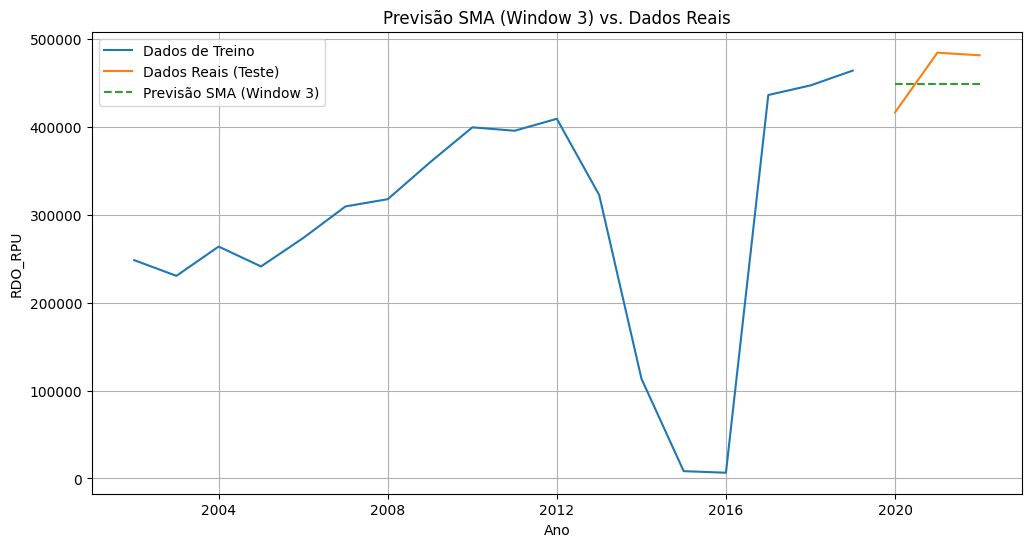

In [22]:
from statsmodels.tsa.api import SimpleExpSmoothing

# Implementar o modelo de Média Móvel Simples (SMA)
window_size = 3
sma_model_name = f'SMA (Window {window_size})'

# Calcular a média móvel nos dados de treino
# Para prever os próximos 3 pontos (test_data), precisamos de 3 valores antes do test_data.index[0]
# O SimpleExpSmoothing com alpha=1.0 e initialization_method="estimated" age como um SMA para os últimos valores.
# No entanto, para uma SMA pura, precisamos aplicar a janela móvel diretamente.
# Para fazer uma previsão de SMA para o futuro, o valor previsto é a última SMA calculada nos dados de treino.

# Calculamos a média móvel nos dados de treino
# A previsão para t+1 é a média dos últimos 'window_size' valores.
# Para prever os 3 pontos do teste, precisamos da média móvel no último ponto de treino.

sma_values = train_data['y'].rolling(window=window_size).mean()

# A previsão para os pontos de teste será o último valor da SMA calculada nos dados de treino
# Se houver valores suficientes no treino para a janela de 3
if len(sma_values) >= window_size:
    last_sma_train = sma_values.iloc[-1]
else:
    # Caso não haja dados suficientes para a janela, use a média simples dos dados de treino
    last_sma_train = train_data['y'].mean()

# A previsão para o período de teste é a repetição do último valor de SMA calculado no treino
forecast_sma = pd.Series([last_sma_train] * len(test_data), index=test_data.index)

# Calcular RMSE e MAE para o modelo SMA
rmse_sma = np.sqrt(mean_squared_error(test_data['y'], forecast_sma))
mae_sma = mean_absolute_error(test_data['y'], forecast_sma)

print(f"\n--- Modelo: {sma_model_name} ---")
print(f"RMSE: {rmse_sma:.2f}")
print(f"MAE: {mae_sma:.2f}")

# Plotar os resultados do modelo SMA
plt.figure(figsize=(12, 6))
plt.plot(train_data['y'], label='Dados de Treino')
plt.plot(test_data['y'], label='Dados Reais (Teste)')
plt.plot(forecast_sma, label=f'Previsão {sma_model_name}', linestyle='--')
plt.title(f'Previsão {sma_model_name} vs. Dados Reais')
plt.xlabel('Ano')
plt.ylabel('RDO_RPU')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Adicionar os resultados do modelo SMA ao DataFrame final de métricas

# Encontrar o índice do modelo 'ETS (No Trend, Additive Error)' para comparação
ets_no_trend_index = final_metrics_df[final_metrics_df['Modelo'] == 'ETS (No Trend, Additive Error)'].index

if not ets_no_trend_index.empty:
    ets_no_trend_rmse = final_metrics_df.loc[ets_no_trend_index[0], 'RMSE']
    ets_no_trend_mae = final_metrics_df.loc[ets_no_trend_index[0], 'MAE']
else:
    print("ETS (No Trend, Additive Error) model not found in metrics, cannot compare directly.")
    ets_no_trend_rmse = np.nan
    ets_no_trend_mae = np.nan

# Criar um DataFrame com os resultados para os modelos de interesse
comparison_models_results = [
    {'Modelo': 'ETS (No Trend, Additive Error)', 'RMSE': ets_no_trend_rmse, 'MAE': ets_no_trend_mae},
    {'Modelo': sma_model_name, 'RMSE': rmse_sma, 'MAE': mae_sma}
]

comparison_df = pd.DataFrame(comparison_models_results)

print("\n--- Comparativo entre ETS (No Trend, Additive Error) e Média Móvel Simples ---")
display(comparison_df.sort_values(by='RMSE'))

# Atualizar o DataFrame final_metrics_df com o modelo SMA
final_metrics_df = pd.concat([final_metrics_df, pd.DataFrame([{'Modelo': sma_model_name, 'RMSE': rmse_sma, 'MAE': mae_sma}])], ignore_index=True)

print("\n--- Comparativo Final de Métricas de Performance (todos os modelos) ---")
display(final_metrics_df.sort_values(by='RMSE'))


--- Comparativo entre ETS (No Trend, Additive Error) e Média Móvel Simples ---


,Modelo,RMSE,MAE
0,"ETS (No Trend, Additive Error)",31547.590601,28456.500084
1,SMA (Window 3),33449.413400,33424.500000



--- Comparativo Final de Métricas de Performance (todos os modelos) ---


,Modelo,RMSE,MAE
4,"ETS (No Trend, Additive Error)",31547.590601,28456.500084
5,SMA (Window 3),33449.413400,33424.500000
2,"ETS (Additive Trend, Additive Error)",38750.507127,31574.955733
3,"ETS (Multiplicative Trend, Multiplicative Error)",38918.352111,31929.253314
0,ARIMA,263220.702768,247466.591124
1,SARIMA,263220.702768,247466.591124


### 3.10 Comparação Visual Detalhada do Melhor Modelo ETS
Vamos visualizar o desempenho do modelo **ETS (No Trend, Additive Error)**, que apresentou as melhores métricas, comparando suas previsões com os dados reais ao longo de todo o período, incluindo os dados de treino e teste.

### 3.11 Previsão do Modelo ETS para os Dados de Treino
Vamos obter as previsões do modelo **ETS (No Trend, Additive Error)** para os dados de treino para avaliar seu ajuste histórico.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


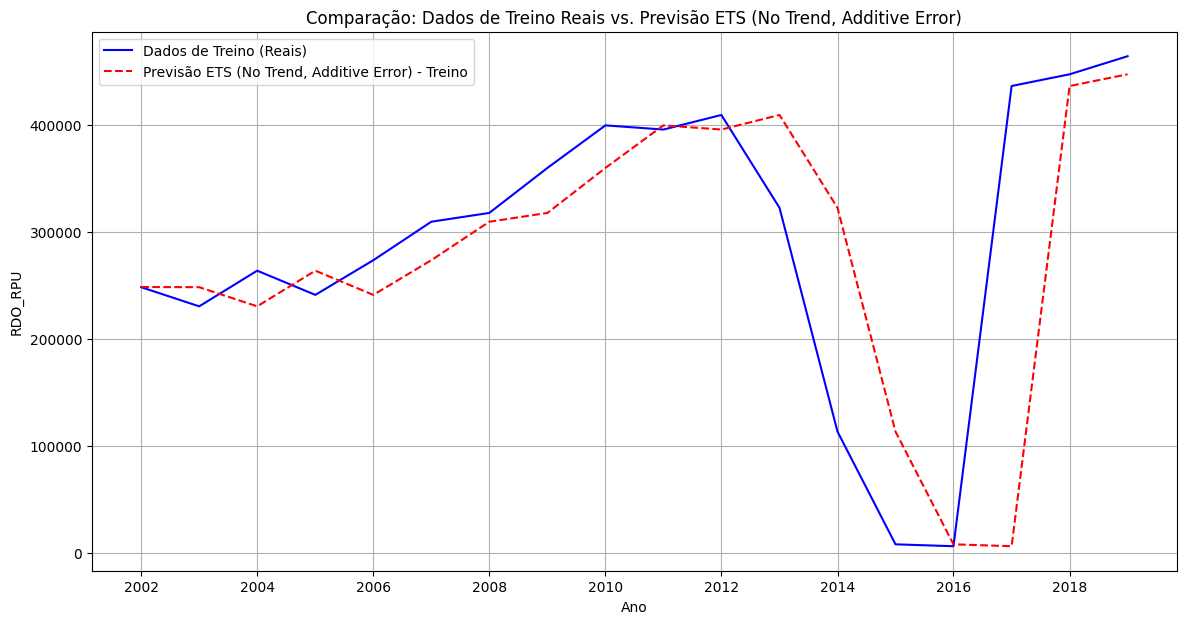

In [25]:
# O modelo ETS (No Trend, Additive Error) foi ajustado como 'model_ets' anteriormente.
# Podemos acessar os valores ajustados para os dados de treino através do atributo 'fittedvalues'.

# Ajustar o modelo ETS (No Trend, Additive Error) novamente para garantir que 'model' esteja disponível
# e para obter os 'fittedvalues' corretos. Este foi o modelo com o melhor desempenho.
model_ets_no_trend_add_error = ExponentialSmoothing(
    train_data['y'],
    trend=None,
    seasonal=None,
    initialization_method="estimated"
).fit()

# Obter as previsões (fitted values) para os dados de treino
forecast_train_ets = model_ets_no_trend_add_error.fittedvalues

plt.figure(figsize=(14, 7))
plt.plot(train_data['y'], label='Dados de Treino (Reais)', color='blue')
plt.plot(forecast_train_ets, label='Previsão ETS (No Trend, Additive Error) - Treino', color='red', linestyle='--')

plt.title('Comparação: Dados de Treino Reais vs. Previsão ETS (No Trend, Additive Error)')
plt.xlabel('Ano')
plt.ylabel('RDO_RPU')
plt.legend()
plt.grid(True)
plt.show()

### 3.12 Previsão do Melhor Modelo ARIMA para os Dados de Treino
Vamos obter as previsões do melhor modelo ARIMA (`ARIMA(3,0,0)`) para os dados de treino para avaliar seu ajuste histórico.

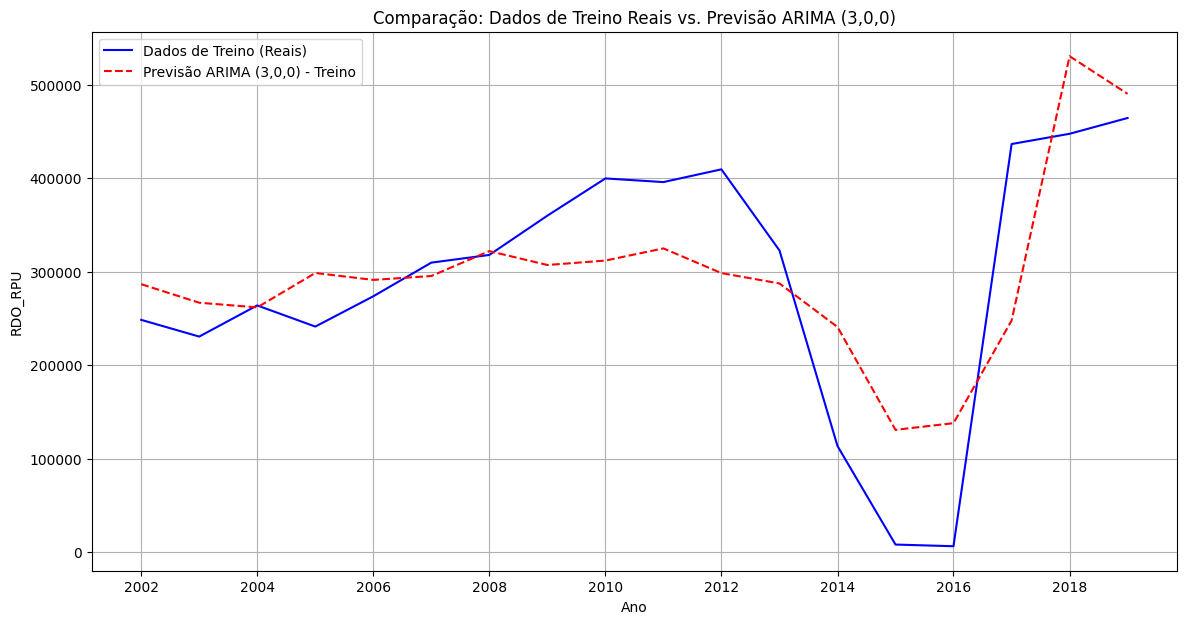

In [26]:
# O melhor modelo ARIMA foi ajustado como 'auto_arima_model' anteriormente.
# Podemos acessar as previsões (fitted values) para os dados de treino usando predict_in_sample().

# Obter as previsões (fitted values) para os dados de treino
forecast_train_arima = auto_arima_model.predict_in_sample()

plt.figure(figsize=(14, 7))
plt.plot(train_data['y'], label='Dados de Treino (Reais)', color='blue')
plt.plot(forecast_train_arima, label='Previsão ARIMA (3,0,0) - Treino', color='red', linestyle='--')

plt.title('Comparação: Dados de Treino Reais vs. Previsão ARIMA (3,0,0)')
plt.xlabel('Ano')
plt.ylabel('RDO_RPU')
plt.legend()
plt.grid(True)
plt.show()